Pradeep Manikandan D
24BAD088

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.preprocessing import LabelEncoder, StandardScaler

from imblearn.over_sampling import SMOTE

In [1]:
#Scenario 1


DT Accuracy: 1.0
Bagging Accuracy: 1.0


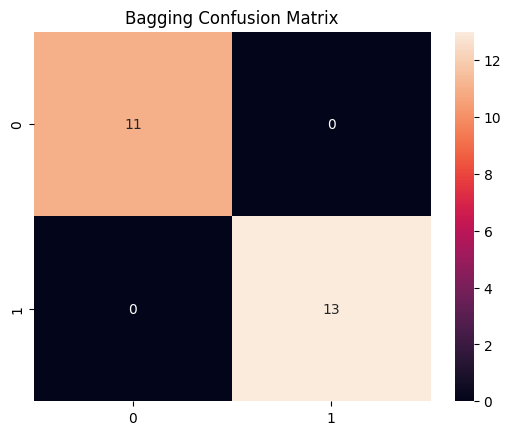

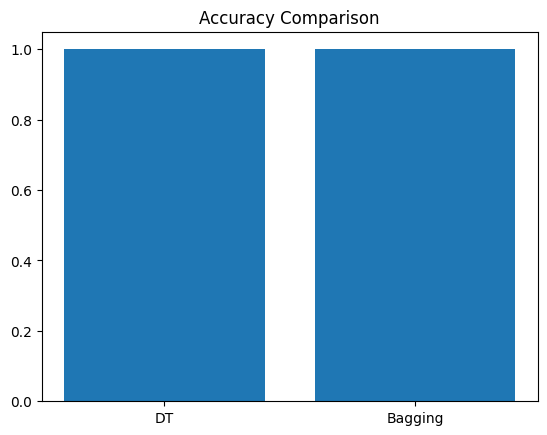

In [5]:
df = pd.read_csv("diabetes_bagging.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Bagging
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

# Accuracy
print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_bag), annot=True)
plt.title("Bagging Confusion Matrix")
plt.show()

# Bar Graph
plt.bar(["DT", "Bagging"], 
        [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_bag)])
plt.title("Accuracy Comparison")
plt.show()

AdaBoost Accuracy: 1.0
Gradient Boost Accuracy: 1.0


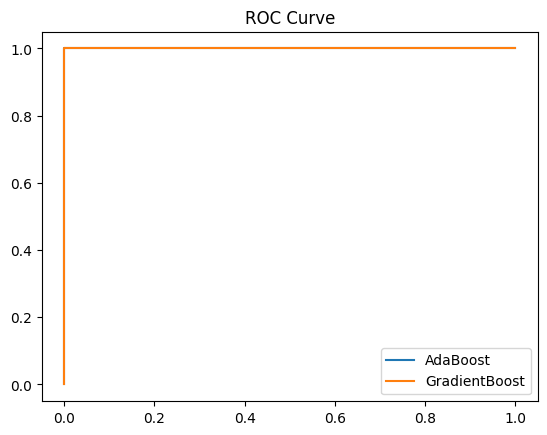

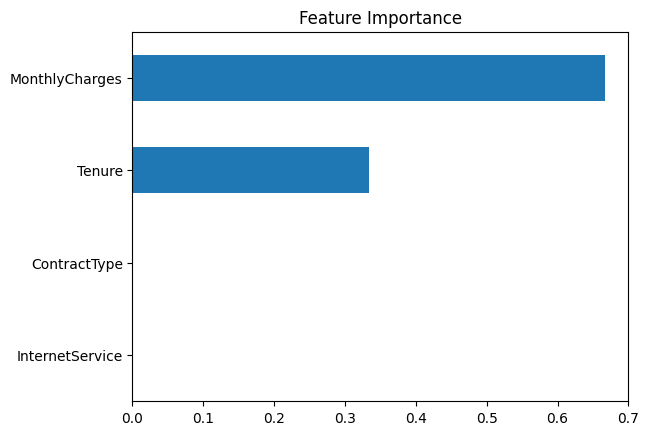

In [6]:
df = pd.read_csv("churn_boosting.csv")

# Encode categorical
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# AdaBoost
ada = AdaBoostClassifier(n_estimators=50)
ada.fit(X_train, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

# Predictions
y_pred_ada = ada.predict(X_test)
y_pred_gb = gb.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Gradient Boost Accuracy:", accuracy_score(y_test, y_pred_gb))

# ROC Curve
for model, name in [(ada, "AdaBoost"), (gb, "GradientBoost")]:
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.legend()
plt.title("ROC Curve")
plt.show()

# Feature Importance
pd.Series(gb.feature_importances_, index=X.columns).sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

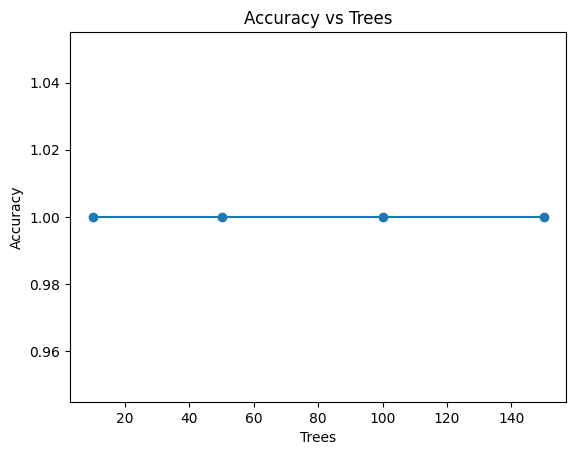

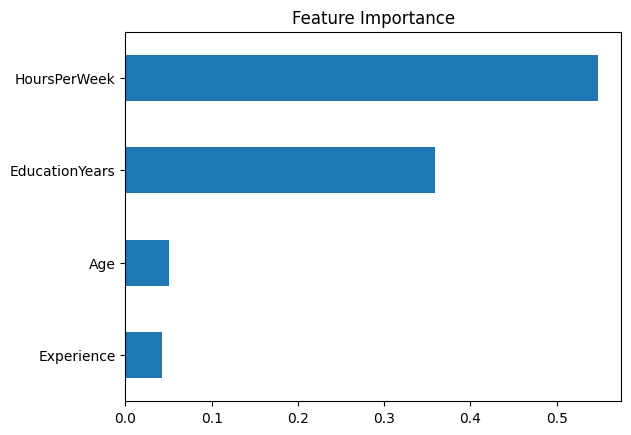

In [7]:
df = pd.read_csv("income_random_forest.csv")

# Encode categorical
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("Income", axis=1)
y = df["Income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

acc = []
trees = [10, 50, 100, 150]

for n in trees:
    rf = RandomForestClassifier(n_estimators=n)
    rf.fit(X_train, y_train)
    acc.append(accuracy_score(y_test, rf.predict(X_test)))

plt.plot(trees, acc, marker='o')
plt.title("Accuracy vs Trees")
plt.xlabel("Trees")
plt.ylabel("Accuracy")
plt.show()

# Feature Importance
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

pd.Series(rf.feature_importances_, index=X.columns).sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

Index(['Age', 'Cholesterol', 'MaxHeartRate', 'RestingBP', 'HeartDisease'], dtype='object')
lr 0.9166666666666666
svm 0.9166666666666666
dt 1.0
Stacking: 1.0


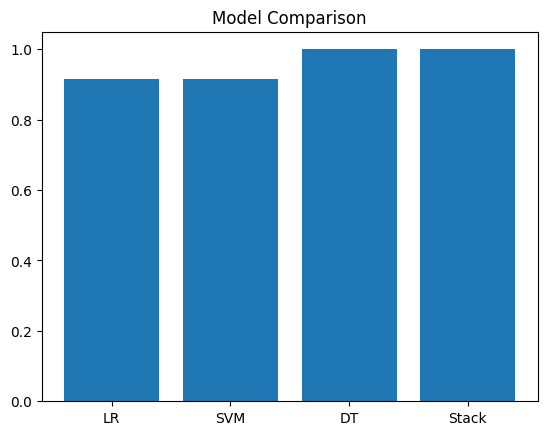

In [11]:
df = pd.read_csv("heart_stacking.csv")
print(df.columns)
# Base models
models = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

# Stacking
stack = StackingClassifier(
    estimators=models,
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)

# Compare models
for name, model in models:
    model.fit(X_train, y_train)
    print(name, accuracy_score(y_test, model.predict(X_test)))

print("Stacking:", accuracy_score(y_test, stack.predict(X_test)))

# Visualization
names = ["LR", "SVM", "DT", "Stack"]
scores = [
    accuracy_score(y_test, LogisticRegression(max_iter=1000).fit(X_train,y_train).predict(X_test)),
    accuracy_score(y_test, SVC(probability=True).fit(X_train,y_train).predict(X_test)),
    accuracy_score(y_test, DecisionTreeClassifier().fit(X_train,y_train).predict(X_test)),
    accuracy_score(y_test, stack.predict(X_test))
]

import matplotlib.pyplot as plt
plt.bar(names, scores)
plt.title("Model Comparison")
plt.show()

After SMOTE:
 Income
0    80
1    80
Name: count, dtype: int64
Before SMOTE: 1.0
After SMOTE: 1.0


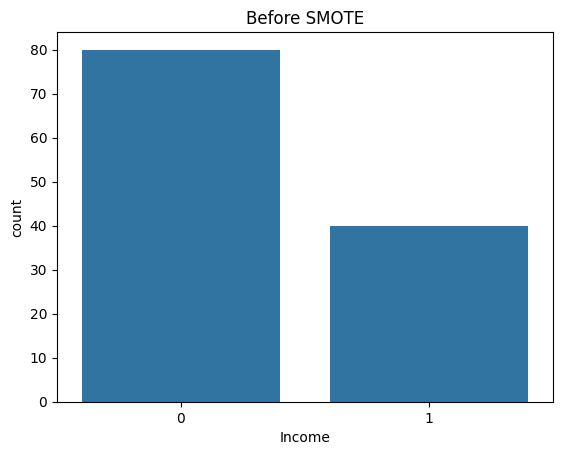

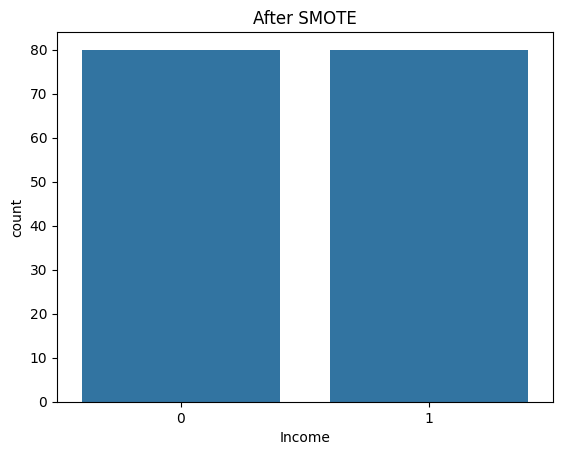

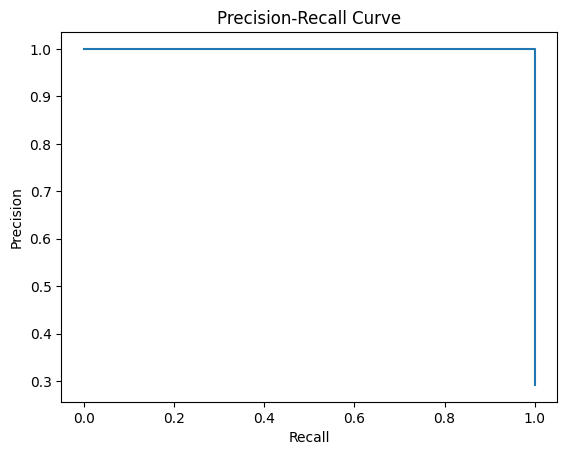

In [13]:
df = pd.read_csv("fraud_smote.csv")
df.columns
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# Apply SMOTE
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)

print("After SMOTE:\n", pd.Series(y_res).value_counts())

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# SMOTE only on training data (IMPORTANT)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Model before SMOTE
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Model after SMOTE
model.fit(X_train_res, y_train_res)
y_pred_res = model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Before SMOTE:", accuracy_score(y_test, y_pred))
print("After SMOTE:", accuracy_score(y_test, y_pred_res))


import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Before SMOTE")
plt.show()

sns.countplot(x=y_res)
plt.title("After SMOTE")
plt.show()


from sklearn.metrics import precision_recall_curve

y_prob = model.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()